In [1]:
from API.database import connect_to_database, fetch_data

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
conn = connect_to_database()
df = fetch_data(conn)
conn.close()

In [4]:
df.head(2)

,id,description,time,distance,frc,currentspeed,freeflowspeed,currenttraveltime,freeflowtraveltime,confidence,roadclosure,latitude,longitude,precip_mm,vis_km,wind_kph,condition_text
0,1854,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,2025-07-22 06:54:00,500,FRC3,21,32,1195,784,1,False,10.765163027177051,106.68176325830919,0.0,10.0,29.2,Light rain
1,1855,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,2025-07-22 06:54:00,400,FRC3,21,32,1195,784,1,False,10.764283334954333,106.68210132878986,0.0,10.0,29.2,Light rain


In [5]:
import pandas as pd

df_transaction = pd.DataFrame()

# Bước 1: Chuẩn bị dữ liệu

In [6]:
df['delay_time'] = df['currenttraveltime'] - df['freeflowtraveltime']
df_transaction['route'] = df["description"].str.replace("Từ ", "").str.strip()

df['hour'] = df['time'].dt.hour
df['date'] = df['time'].dt.date
df_filtered = df[df['hour'].isin([6, 7, 11, 12, 16])]
df_transaction['period'] = pd.cut(df_filtered['hour'],
                                  bins=[6, 8, 12, 17],
                                  labels=['Sáng', 'Trưa', 'Chiều'],
                                  right=False)

df_transaction['rain'] = pd.cut(df_filtered['precip_mm'],
                                bins=[-float('inf'), 0, 2.5, float('inf')],
                                labels=['Không mưa', 'Mưa nhẹ', 'Mưa lớn'],
                                right=True)

df_transaction['wind'] = pd.cut(df_filtered['wind_kph'],
                                        bins=[-float('inf'), 10, 20, float('inf')],
                                        labels=['Yên lặng', 'Gió vừa', 'Gió mạnh'],
                                        right=True)

df_transaction['visibility'] = pd.cut(df_filtered['vis_km'],
                                      bins=[0, 5, 10, float('inf')],
                                      labels=['Tầm nhìn thấp', 'Tầm nhìn trung bình', 'Tầm nhìn cao'],
                                      right=True)

df_transaction['waiting'] = pd.cut(df['delay_time'],
                                   bins=[0, 300, 600, float('inf')],
                                   labels=['Chờ không đáng kể', 'Chờ chấp nhận được', 'Chờ lâu'],
                                   right=True)

df_transaction = df_transaction.dropna()  # Loại null nếu có
df_transaction

,route,period,rain,wind,visibility,waiting
0,Ngã Sáu Cộng Hòa đến An Dương Vương,Sáng,Không mưa,Gió mạnh,Tầm nhìn trung bình,Chờ chấp nhận được
1,Ngã Sáu Cộng Hòa đến An Dương Vương,Sáng,Không mưa,Gió mạnh,Tầm nhìn trung bình,Chờ chấp nhận được
2,Ngã Sáu Cộng Hòa đến An Dương Vương,Sáng,Không mưa,Gió mạnh,Tầm nhìn trung bình,Chờ chấp nhận được
3,Ngã Sáu Cộng Hòa đến An Dương Vương,Sáng,Không mưa,Gió mạnh,Tầm nhìn trung bình,Chờ chấp nhận được
4,Ngã Sáu Cộng Hòa đến An Dương Vương,Sáng,Không mưa,Gió mạnh,Tầm nhìn trung bình,Chờ chấp nhận được
...,...,...,...,...,...,...
11645,Vòng Xoay Trần Phú đến ĐHSP,Chiều,Mưa nhẹ,Gió vừa,Tầm nhìn trung bình,Chờ không đáng kể
11646,Vòng Xoay Trần Phú đến ĐHSP,Chiều,Mưa nhẹ,Gió vừa,Tầm nhìn trung bình,Chờ không đáng kể
11647,Vòng Xoay Trần Phú đến ĐHSP,Chiều,Mưa nhẹ,Gió vừa,Tầm nhìn trung bình,Chờ không đáng kể
11648,Vòng Xoay Trần Phú đến ĐHSP,Chiều,Mưa nhẹ,Gió vừa,Tầm nhìn trung bình,Chờ không đáng kể


In [7]:
import numpy as np
import random

transactions = df_transaction.apply(
    lambda row: [
        row["route"],
        row["period"],
        row["rain"],
        row["visibility"],
        row["wind"],
        row["waiting"]
    ],
    axis=1
).tolist()

sample_transactions = random.sample(transactions, 10)
unique_transactions = [list(t) for t in set(tuple(x) for x in transactions)]

print("Ví dụ 10 transaction ngẫu nhiên:")
print(np.array(sample_transactions))
print(f"Tổng cộng có: {len(transactions)} giao dịch," \
      f" trong đó có {len(unique_transactions)} giao dịch khác nhau đôi một")

Ví dụ 10 transaction ngẫu nhiên:
[['Vòng Xoay Trần Phú đến ĐHSP' 'Trưa' 'Không mưa' 'Tầm nhìn trung bình'
  'Gió vừa' 'Chờ không đáng kể']
 ['Ngã Sáu Cộng Hòa đến An Dương Vương' 'Sáng' 'Không mưa'
  'Tầm nhìn trung bình' 'Gió mạnh' 'Chờ không đáng kể']
 ['Vòng Xoay Trần Phú đến ĐHSP' 'Trưa' 'Mưa nhẹ' 'Tầm nhìn trung bình'
  'Gió vừa' 'Chờ không đáng kể']
 ['Vòng Xoay Trần Phú đến ĐHSP' 'Trưa' 'Không mưa' 'Tầm nhìn thấp'
  'Gió vừa' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Sáng' 'Mưa nhẹ'
  'Tầm nhìn trung bình' 'Gió mạnh' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Chiều' 'Không mưa'
  'Tầm nhìn trung bình' 'Gió vừa' 'Chờ không đáng kể']
 ['Ngã Sáu Cộng Hòa đến An Dương Vương' 'Sáng' 'Mưa nhẹ'
  'Tầm nhìn trung bình' 'Gió vừa' 'Chờ chấp nhận được']
 ['Vòng Xoay Trần Phú đến ĐHSP' 'Chiều' 'Mưa nhẹ' 'Tầm nhìn trung bình'
  'Yên lặng' 'Chờ không đáng kể']
 ['Vòng Xoay Trần Phú đến ĐHSP' 'Sáng' 'Mưa nhẹ' 'Tầm nhìn trung bình'
  'Gió mạnh' 'Chờ khôn

# Bước 2: Chọn ngưỡng tham số (support và confidence)
**Support (Độ hỗ trợ):**
Tỉ lệ giao dịch có cả A và B. → Cho biết luật đó xuất hiện phổ biến hay hiếm.

**Confidence (Độ tin cậy):**
Xác suất mua B khi đã mua A. → Cho biết độ mạnh của mối quan hệ.


In [8]:
df_transaction['waiting'].unique()

['Chờ chấp nhận được', 'Chờ không đáng kể', 'Chờ lâu']
Categories (3, object): ['Chờ không đáng kể' < 'Chờ chấp nhận được' < 'Chờ lâu']

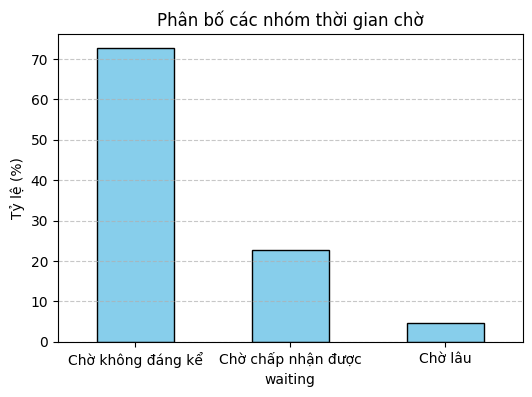

Tỷ lệ phần trăm các nhóm thời gian chờ:
waiting
Chờ không đáng kể     72.616055
Chờ chấp nhận được    22.808782
Chờ lâu                4.575163
Name: proportion, dtype: float64


In [9]:
import matplotlib.pyplot as plt

# Đếm tần suất từng nhóm thời gian chờ
waiting_counts = df_transaction['waiting'].value_counts(normalize=True) * 100

# Vẽ biểu đồ cột
plt.figure(figsize=(6,4))
waiting_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel("Tỷ lệ (%)")
plt.title("Phân bố các nhóm thời gian chờ")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Tỷ lệ phần trăm các nhóm thời gian chờ:")
print(waiting_counts)

📝 Biện luận lựa chọn tham số
**1. Support**

Nhóm “Chờ lâu” chỉ chiếm khoảng 4.6% dữ liệu. Nếu đặt ngưỡng `min_support` quá cao (ví dụ 0.1 = 10%), toàn bộ các luật liên quan đến “Chờ lâu” sẽ bị loại bỏ.

Nhóm “Chờ chấp nhận được” chiếm ~22.8%, nhóm này dễ đạt support cao hơn nên ít bị ảnh hưởng.

Nhóm “Chờ không đáng kể” chiếm đa số (72.6%), nên mọi luật liên quan tới nhóm này đều có support cao, nhưng có nguy cơ trở thành luật hiển nhiên (trivial rules).

👉 Vì vậy, để giữ được các luật quan trọng nhưng hiếm (liên quan tới “Chờ lâu”), ta nên đặt: `min_support ≈ 0.02`
  
Tương ứng với việc các luật cần xuất hiện ít nhất ~120 lần trong tổng 5967 giao dịch.


**2. Confidence**

Nếu đặt ≥0.7 thì toàn bộ các luật liên quan đến “Chờ lâu” sẽ biến mất.

Chọn ngưỡng 0.5 để vẫn giữ lại các luật quan trọng về hiện tượng hiếm.

Luật có confidence 0.5 nghĩa là: trong ít nhất một nửa số trường hợp antecedent xảy ra thì consequent cũng xảy ra.

👉 Đề xuất: `min_confidence ≈ 0.5`

In [10]:
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.5

# Bước 3: Tìm các itemsets phổ biến

In [11]:
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print("Top 5 itemsets phổ biến:")
print(frequent_itemsets.head(5))
print(f"5 Itemsets cuối cùng:\n {frequent_itemsets.tail(5)}")
print(f"\nTổng số lượng itemsets: {len(frequent_itemsets)}")

Top 5 itemsets phổ biến:
     support                                  itemsets
13  0.967153                     (Tầm nhìn trung bình)
2   0.726161                       (Chờ không đáng kể)
45  0.707558  (Chờ không đáng kể, Tầm nhìn trung bình)
7   0.616390                               (Không mưa)
80  0.608681          (Không mưa, Tầm nhìn trung bình)
5 Itemsets cuối cùng:
       support                                           itemsets
340  0.020278  (Trưa, Chờ chấp nhận được, Gió mạnh, Ngã Sáu C...
208  0.020278          (Chờ lâu, Không mưa, Tầm nhìn trung bình)
524  0.020278  (Chờ chấp nhận được, Ngã Sáu Cộng Hòa đến An D...
324  0.020111  (Chiều, Ngã Sáu Cộng Hòa đến An Dương Vương, T...
121  0.020111  (Chiều, Ngã Sáu Cộng Hòa đến An Dương Vương, G...

Tổng số lượng itemsets: 616



Số lượng itemsets theo độ dài:
length
1     16
2     87
3    197
4    205
5     96
6     15
Name: count, dtype: int64


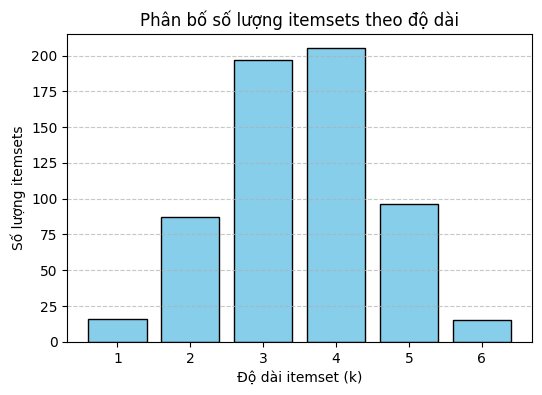

In [12]:
# Thêm cột 'length' = số phần tử trong itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Đếm số lượng itemsets theo độ dài
length_counts = frequent_itemsets['length'].value_counts().sort_index()
print("\nSố lượng itemsets theo độ dài:")
print(length_counts)

# Vẽ biểu đồ cột
plt.figure(figsize=(6,4))
plt.bar(length_counts.index, length_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Độ dài itemset (k)')
plt.ylabel('Số lượng itemsets')
plt.title('Phân bố số lượng itemsets theo độ dài')
plt.xticks(length_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
frequent_itemsets[frequent_itemsets['length'].isin([1])]

,support,itemsets,length
13,0.967153,(Tầm nhìn trung bình),1
2,0.726161,(Chờ không đáng kể),1
7,0.616390,(Không mưa),1
6,0.537791,(Gió vừa),1
10,0.510977,(Sáng),1
14,0.428188,(Vòng Xoay Trần Phú đến ĐHSP),1
8,0.382940,(Mưa nhẹ),1
5,0.346070,(Gió mạnh),1
11,0.335177,(Trưa),1
4,0.327468,(Cầu Nguyễn Văn Cừ đến An Dương Vương),1


# Bước 4. Sinh luật kết hợp

In [14]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
print("Các luật kết hợp:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Các luật kết hợp:
             antecedents            consequents   support  confidence  \
0    (Chờ không đáng kể)  (Tầm nhìn trung bình)  0.707558    0.974383   
1  (Tầm nhìn trung bình)    (Chờ không đáng kể)  0.707558    0.731589   
2            (Không mưa)  (Tầm nhìn trung bình)  0.608681    0.987493   
3  (Tầm nhìn trung bình)            (Không mưa)  0.608681    0.629354   
4  (Tầm nhìn trung bình)              (Gió vừa)  0.504944    0.522093   
5              (Gió vừa)  (Tầm nhìn trung bình)  0.504944    0.938922   
6                 (Sáng)  (Tầm nhìn trung bình)  0.502598    0.983601   
7  (Tầm nhìn trung bình)                 (Sáng)  0.502598    0.519667   
8            (Không mưa)    (Chờ không đáng kể)  0.452489    0.734095   
9    (Chờ không đáng kể)            (Không mưa)  0.452489    0.623125   

       lift  
0  1.007476  
1  1.007476  
2  1.021031  
3  1.021031  
4  0.970810  
5  0.970810  
6  1.017007  
7  1.017007  
8  1.010926  
9  1.010926  


In [15]:
rules_high_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ lâu"})]
rules_medium_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ chấp nhận được"})]
rules_low_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ không đáng kể"})]

rules_high_wait = rules_high_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

rules_medium_wait = rules_medium_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

rules_low_wait = rules_low_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

print(f"Tổng số luật cho thời gian chờ lâu (trên 600 giây): {len(rules_high_wait)}")
print(f"Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): {len(rules_medium_wait)}")
print(f"Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): {len(rules_low_wait)}")

Tổng số luật cho thời gian chờ lâu (trên 600 giây): 4
Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): 40
Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): 201


# Bước 5. Đánh giá luật

**Lift (Hệ số nâng đỡ):**
Đo xem luật có ý nghĩa thực sự không, bằng cách so sánh với trường hợp ngẫu nhiên.
- Lift = 1 → không có ý nghĩa
- Lift > 1 → A và B đi cùng nhau nhiều hơn ngẫu nhiên
- Lift < 1 → A và B ít đi cùng nhau

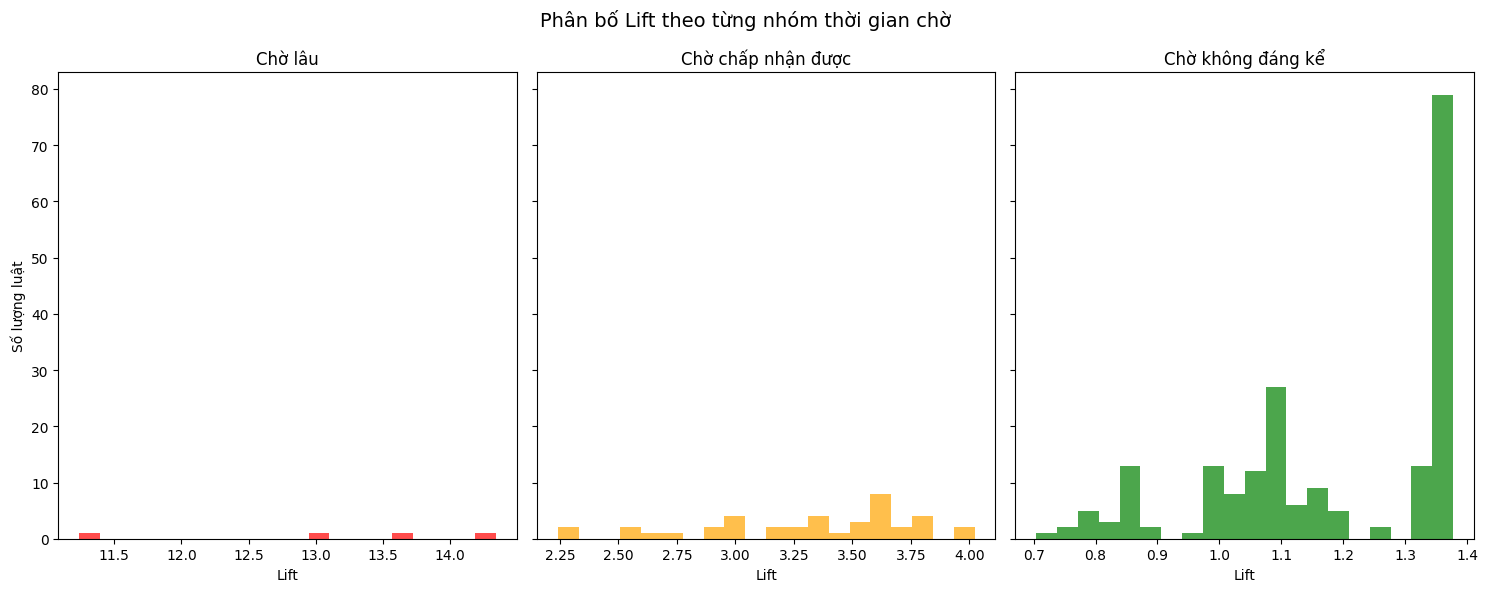

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)  # 1 hàng, 3 cột

# Histogram cho "Chờ lâu"
axes[0].hist(rules_high_wait['lift'], bins=20, color="red", alpha=0.7)
axes[0].set_title("Chờ lâu")
axes[0].set_xlabel("Lift")
axes[0].set_ylabel("Số lượng luật")

# Histogram cho "Chờ chấp nhận được"
axes[1].hist(rules_medium_wait['lift'], bins=20, color="orange", alpha=0.7)
axes[1].set_title("Chờ chấp nhận được")
axes[1].set_xlabel("Lift")

# Histogram cho "Chờ không đáng kể"
axes[2].hist(rules_low_wait['lift'], bins=20, color="green", alpha=0.7)
axes[2].set_title("Chờ không đáng kể")
axes[2].set_xlabel("Lift")

plt.suptitle("Phân bố Lift theo từng nhóm thời gian chờ", fontsize=14)
plt.tight_layout()
plt.show()

Chọn `min_lift  ≈ 1.3` do quan sát biểu đồ "Phân bố lift theo nhóm chờ không đáng kể" cho thấy lift >= 1.3 thuộc phạm vi chấp nhận được để chắn rằng những luật này không phát sinh từ ngẫu nhiên

In [17]:
MIN_LIFT = 1.3

rules_high_wait_lift = rules_high_wait[rules_high_wait['lift'] >= MIN_LIFT]
rules_medium_wait_lift = rules_medium_wait[rules_medium_wait['lift'] >= MIN_LIFT]
rules_low_wait_lift = rules_low_wait[rules_low_wait['lift'] >= MIN_LIFT]


print(f"Tổng số luật cho thời gian chờ lâu (trên 600 giây): {len(rules_high_wait_lift)}")
print(f"Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): {len(rules_medium_wait_lift)}")
print(f"Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): {len(rules_low_wait_lift)}")

Tổng số luật cho thời gian chờ lâu (trên 600 giây): 4
Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): 40
Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): 92


# Bước 6. Ứng dụng

Chọn ra top 10 luật cho mỗi nhóm thời gian chờ

In [18]:
TOP_K = 10

In [19]:
# Top 5 luật "Chờ lâu"
top5_high = rules_high_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Top 5 luật "Chờ chấp nhận được"
top5_medium = rules_medium_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Top 5 luật "Chờ không đáng kể"
top5_low = rules_low_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print(f"🔴 Top {TOP_K} luật với hậu quả - Chờ lâu:")
print(top5_high, "\n")

print(f"🟠 Top {TOP_K} luật với hậu quả - Chờ chấp nhận được:")
print(top5_medium, "\n")

print(f"🟢 Top {TOP_K} luật với hậu quả - Chờ không đáng kể:")
print(top5_low)

🔴 Top 10 luật với hậu quả - Chờ lâu:
                                            antecedents consequents   support  \
1733  (Trưa, Ngã Sáu Cộng Hòa đến An Dương Vương, Mư...   (Chờ lâu)  0.021116   
1360  (Trưa, Ngã Sáu Cộng Hòa đến An Dương Vương, Gi...   (Chờ lâu)  0.031004   
1525  (Trưa, Ngã Sáu Cộng Hòa đến An Dương Vương, Tầ...   (Chờ lâu)  0.025976   
1067        (Trưa, Ngã Sáu Cộng Hòa đến An Dương Vương)   (Chờ lâu)  0.042400   

      confidence       lift  
1733    0.656250  14.343750  
1360    0.622896  13.614719  
1525    0.593870  12.980296  
1067    0.514228  11.239547   

🟠 Top 10 luật với hậu quả - Chờ chấp nhận được:
                                            antecedents           consequents  \
1477  (Không mưa, Sáng, Ngã Sáu Cộng Hòa đến An Dươn...  (Chờ chấp nhận được)   
1487  (Không mưa, Sáng, Ngã Sáu Cộng Hòa đến An Dươn...  (Chờ chấp nhận được)   
1125  (Gió mạnh, Sáng, Ngã Sáu Cộng Hòa đến An Dương...  (Chờ chấp nhận được)   
1129  (Gió mạnh, Sáng, Ngã Sáu Cộ

In [ ]:
output_file = "API/Top5_rules_each_group.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for label, df in [
        ("Chờ lâu", top5_high),
        ("Chờ chấp nhận được", top5_medium),
        ("Chờ không đáng kể", top5_low)
    ]:
        f.write(f"\n==========================================\n")
        f.write(f"🔹 Nhóm hậu quả: {label}\n")
        f.write("=============================================\n\n")

        for _, row in df.iterrows():
            f.write(f"Hậu quả (consequents): {', '.join(list(row['consequents']))}\n")
            f.write(f"Các tác nhân (antecedents): {', '.join(list(row['antecedents']))}\n")
            f.write(f"Độ phổ biến (support): {row['support']:.4f}\n")
            f.write(f"Độ tin cậy (confidence): {row['confidence']:.4f}\n")
            f.write(f"Độ phụ thuộc (lift): {row['lift']:.4f}\n")
            f.write("----------------------------------------\n")

print(f"✅ Đã lưu kết quả vào file: {output_file}")

✅ Đã lưu kết quả vào file: API/Top5_rules_each_group.txt


: 